## Connect to Big Query

In [ ]:
from google.cloud import bigquery
from google.colab import auth
import numpy as np
import pandas as pd

auth.authenticate_user()

project_id = 'my-project-echurn102025'
client = bigquery.Client(project = project_id , location = 'US')

In [ ]:
datatset_reference = client.dataset('employeedata' , project = project_id)
dataset = client.get_dataset(datatset_reference)
table_reference = dataset.table('tbl_hr_data')
table = client.get_table(table_reference)
table.schema

[SchemaField('satisfaction_level', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('last_evaluation', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('number_project', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('average_montly_hours', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('time_spend_company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Work_accident', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Quit_the_Company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('promotion_last_5years', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Departments', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('salary', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('employee_id', 'STRING', 'NULLABLE', None, None, (), None)]

In [ ]:
table_reference_new = dataset.table('tbl_new_employees')
table_new = client.get_table(table_reference_new)

In [ ]:
#create dataframes from Big Query tables

df = client.list_rows(table = table).to_dataframe()
df2 = client.list_rows(table = table_new).to_dataframe() #contains unseen final data to be used for predictions


In [ ]:
df.info()
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15004 entries, 0 to 15003
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     15004 non-null  float64
 1   last_evaluation        15004 non-null  float64
 2   number_project         14999 non-null  Int64  
 3   average_montly_hours   15004 non-null  Int64  
 4   time_spend_company     14999 non-null  Int64  
 5   Work_accident          15000 non-null  Int64  
 6   Quit_the_Company       15004 non-null  Int64  
 7   promotion_last_5years  15004 non-null  Int64  
 8   Departments            15004 non-null  object 
 9   salary                 15004 non-null  object 
 10  employee_id            15004 non-null  object 
dtypes: Int64(6), float64(2), object(3)
memory usage: 1.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype

In [ ]:
df2.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.537849,0.122914,2,208,2,0,0,0,IT,high,NE15043
1,0.056211,0.322600,2,229,5,1,0,0,IT,low,NE15086
2,0.555186,0.555949,2,187,3,0,0,0,RandD,medium,NE15035
3,0.605273,0.713086,2,218,3,0,0,0,RandD,high,NE15069
4,0.043437,0.162372,2,175,3,0,0,0,RandD,high,NE15082


## Data preprocessing

Tasks performed
- One hot encoding categorical features (salary and department)
- Changing case of features to lower
- Fixing any typos or inconsistent feature names

In [ ]:
df_processed = pd.DataFrame(df)
df2_processed = pd.DataFrame(df2)

df_processed = pd.get_dummies(df, columns=['salary','Departments'],prefix=['salary','department'],prefix_sep='_' , dtype = int)
cols= df_processed.columns.tolist()
df_processed.columns = [x.lower() for x in cols]
df_processed.columns

#2nd dataframe

df2_processed = pd.get_dummies(df2, columns=['salary' , 'Departments'], prefix =['salary', 'department'] , prefix_sep='_' , dtype =int)
cols2 = df2_processed.columns.tolist()
df2_processed.columns = [x.lower() for x in cols2]
df2_processed.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'work_accident',
       'quit_the_company', 'promotion_last_5years', 'employee_id',
       'salary_high', 'salary_low', 'salary_medium', 'department_it',
       'department_randd', 'department_accounting', 'department_hr',
       'department_management', 'department_marketing',
       'department_product_mng', 'department_sales', 'department_support',
       'department_technical'],
      dtype='object')

In [ ]:
df_processed.rename(columns = {"average_montly_hours" : "average_monthly_hours"}, inplace = True)
df2_processed.rename(columns = {"average_montly_hours" : "average_monthly_hours"},inplace = True)

## Build Models

Now we will initialize three different classification models and assess which one is the best choice for our particular use.


Models:
- [K Nearest Neighbor (KNN)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier)
- [Support Vector Machine (SVM)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)
- [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)




### Code and Train Model

In [ ]:
#get our models and evaluation methods

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , GridSearchCV , StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Initializing Models & Comparison
### Data Preprocessing (For KNN)

In [ ]:
#create our data frames for
X = df_processed.drop(columns = ['quit_the_company' , 'employee_id'])
y = df_processed['quit_the_company']

X_train , X_test, y_train, y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

nan_total_train = X_train.isnull().sum() #tally NaN values in training data Before processing
nan_total_test = X_test.isnull().sum()


#tally of nan values in our dataframes
print(f"Original number of NaN values was: {nan_total_train}\n")
print("______________________________________________________\n")
print(f"Original number of NaN values in testing dataframe is : {nan_total_test}")

Original number of NaN values was: satisfaction_level        0
last_evaluation           0
number_project            4
average_monthly_hours     0
time_spend_company        4
work_accident             3
promotion_last_5years     0
salary_high               0
salary_low                0
salary_medium             0
department_it             0
department_randd          0
department_accounting     0
department_hr             0
department_management     0
department_marketing      0
department_product_mng    0
department_sales          0
department_support        0
department_technical      0
dtype: int64

______________________________________________________

Original number of NaN values in testing dataframe is : satisfaction_level        0
last_evaluation           0
number_project            1
average_monthly_hours     0
time_spend_company        1
work_accident             1
promotion_last_5years     0
salary_high               0
salary_low                0
salary_medium             0

Now with we'll optimize KNN model with the use of pipelines.

In [ ]:
from sklearn.impute import SimpleImputer

#initalize the pipeline and it's transformers / estimators
pipeline = Pipeline(steps=[
('imputer', SimpleImputer(strategy='mean')), #replaces missing values with the mean of the feature
('scaler' , StandardScaler()), #scale the feature values to ensure "equal" contributions to KNN model
('pca', PCA()), #Principle Component Analysis - to reduce features to the minimal set of orthogonal components
('knn', KNeighborsClassifier()) #our KNN model
])

#the PCA and KNN parameters that we will be assessing our model with
param_grid = {'pca__n_components' : [2,3],
              'knn__n_neighbors' : [2,3,4,5,6,7] #number of nearest points used to classify a given observation
              }

#cross validation via 5 Strafied Folds
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

Iterate through the KNN parameters until we find the optimal combination, using [`GridSearchCV()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

In [ ]:
best_model_knn = GridSearchCV(estimator = pipeline ,
                          param_grid = param_grid,
                          cv = cv ,
                          scoring = 'accuracy',
                          verbose = 2
                          )

In [ ]:
best_model_knn.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ............knn__n_neighbors=2, pca__n_components=2; total time=   0.1s
[CV] END ............knn__n_neighbors=2, pca__n_components=2; total time=   0.3s
[CV] END ............knn__n_neighbors=2, pca__n_components=2; total time=   0.1s
[CV] END ............knn__n_neighbors=2, pca__n_components=2; total time=   0.1s
[CV] END ............knn__n_neighbors=2, pca__n_components=2; total time=   0.1s
[CV] END ............knn__n_neighbors=2, pca__n_components=3; total time=   0.3s
[CV] END ............knn__n_neighbors=2, pca__n_components=3; total time=   0.3s
[CV] END ............knn__n_neighbors=2, pca__n_components=3; total time=   0.3s
[CV] END ............knn__n_neighbors=2, pca__n_components=3; total time=   0.3s
[CV] END ............knn__n_neighbors=2, pca__n_components=3; total time=   0.4s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.1s
[CV] END ............knn__n_neighbors=3, pca__n_

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [2, 3, 4, 5, 6, 7],
                         'pca__n_components': [2, 3]},
             scoring='accuracy', verbose=2)

If we expand the information under the elements of our pipeline (in GridSearchCV graphic produced in the ouput), we see that our selected parameters were 2 and 3 for the number of nearest neighbors and the PCA components respectively.


Next , we find the accuracy score of our KNN model using the test data.

In [ ]:
test_score = best_model_knn.score(X_test,y_test)
print(f"{test_score:.3f}")

0.946


In [ ]:
best_model_knn.best_params_

{'knn__n_neighbors': 2, 'pca__n_components': 3}




Now that we have our ideal KNN model. We'll return it's employee churn predictions up ahead. We will also assess how it performed with a Confusion Matrix and some useful metrics.

Lets initialize pipelines for our other classifier models. Specifically a RandomForest Classifier and a Support Vector Machine model.

In [ ]:
pipeline_rf = Pipeline( steps=[
    ('imputer' , SimpleImputer(strategy = 'mean')) , # replace missing values with the mean of the feature
    ('scaler' , StandardScaler()),
    ('rfc' , RandomForestClassifier(random_state = 42))
])

pipeline_svm = Pipeline ( steps=[
    ('imputer' , SimpleImputer(strategy = 'mean')) ,
    ('scaler' , StandardScaler()),
    ('svm' , SVC(kernel = 'linear', C=1 , random_state = 42))
])

Train the models

In [ ]:
model_rf = pipeline_rf.fit(X_train, y_train)
model_svm = pipeline_svm.fit(X_train, y_train)

### Evaluating the Classification Models

Tools & metrics that we will use :
- Confusion Matrices
- Classification Reports :
  - Recall
  - Precision
  - F1-Score


#### Background Information

Some preliminaries. In this context, since we are assessing the risk of employee churn. A "positive" corresponds to 1 , i.e. employee churn , negative corresponds to 0, i.e. employee retained.

So a true positive is a correctly predicted case of employee churn while a false positive is the case where our model predicted that a given employee was churned when they were retained in actuality.

True positive: prediction $= 1 =$ actual value

False positive: prediction $= 1 $ and  actual value $= 0$

True negative: prediction $= 0 =$ actual value

False negative: prediction $= 0 $ and  actual value $= 1$


In [ ]:
y_pred_knn = best_model_knn.predict(X_test)
y_pred_svm = model_svm.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

model_preds = [y_pred_knn, y_pred_svm , y_pred_rf]
class_algs = ['KNN' ,'SVM', 'Random Forest']

#give us the accuracy score and classification reports for our models
for i, j in zip(model_preds,class_algs) :
  print(f"The accuracy score for {j} is {accuracy_score(y_test, i):.3f}\n" )
  print(f"\n The classification report for {j} is: \n")
  print("\n" , classification_report(y_test, i))
  print(f"______________________________________________________\n")


The accuracy score for KNN is 0.946


 The classification report for KNN is: 


               precision    recall  f1-score   support

         0.0       0.95      0.98      0.96      2281
         1.0       0.92      0.85      0.88       720

    accuracy                           0.95      3001
   macro avg       0.94      0.91      0.92      3001
weighted avg       0.95      0.95      0.94      3001

______________________________________________________

The accuracy score for SVM is 0.770


 The classification report for SVM is: 


               precision    recall  f1-score   support

         0.0       0.79      0.94      0.86      2281
         1.0       0.55      0.23      0.32       720

    accuracy                           0.77      3001
   macro avg       0.67      0.58      0.59      3001
weighted avg       0.74      0.77      0.73      3001

______________________________________________________

The accuracy score for Random Forest is 0.991


 The classification repo

Based on these classification reports I am highly inclined to pick the Random Forest Classifier as our model of choice.

But let's carry on with the next assessment, the confusion matrices. Which will give us a closer look into the number of true or false positive/negatives in our models' predictions.

#### Confusion Matrices

Using a combinatin of [confusion matrices](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) and [heatmaps](https://seaborn.pydata.org/generated/seaborn.heatmap.html) we will visualize a comparison between our models' predictions and the actual outcomes of our employee churn training data.

First we initialize our confusion matrices and then we visualize them using heatmaps from the statstical data visualization library, [Seaborn](https://seaborn.pydata.org/index.html).


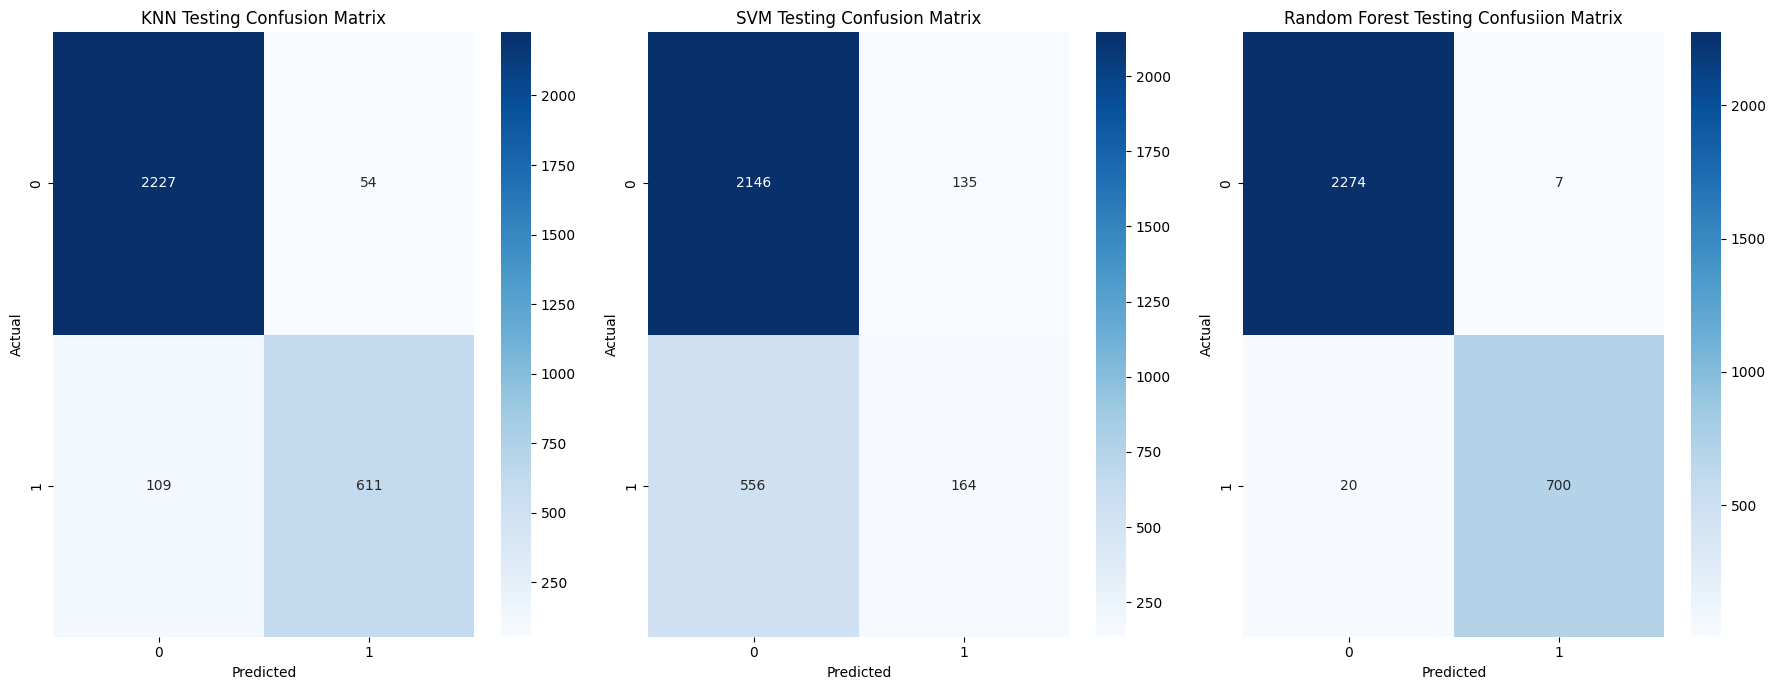

In [ ]:
conf_matrix_knn = confusion_matrix(y_test , y_pred_knn)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)


fig, axes = plt.subplots(1,3, figsize = (18,7))

#knn heatmap subplot for knn confusion matrix
sns.heatmap(conf_matrix_knn , annot=True , cmap='Blues' , fmt = 'd', ax = axes[0] , xticklabels = 'auto' , yticklabels = 'auto' )
axes[0].set_title("KNN Testing Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

#svm heatmap subplot

sns.heatmap(conf_matrix_svm, annot=True, cmap='Blues' , fmt = 'd' , ax = axes[1] , xticklabels = 'auto', yticklabels = 'auto')
axes[1].set_title("SVM Testing Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

#rf heatmap subplot

sns.heatmap(conf_matrix_rf, annot=True , cmap='Blues' , fmt = 'd' , ax = axes[2] , xticklabels = 'auto' , yticklabels = 'auto')
axes[2].set_title("Random Forest Testing Confusiion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Here we can see that our Random Forest classifier is the better performing of the three models.

To further instill the information discussed prior. We can breakdown the predictions of our Random Forest classifier in the following manner:
- True Positives count: 700
- False Positives count: 7
- True Negatives count: 2274
- False Negatives count: 20

Now the results of our classification report should seem clearer.

Below are the formulas for the metrics in our classification report , in respect to employee churn (1).




$$\text{Precision }= \displaystyle\frac{\text{True positives}}{\text{True Positives} + \text{ False Positives}} = \frac{700}{707} \approx 0.99 \\ $$



$$\text{Recall }= \displaystyle\frac{\text{True positives}}{\text{True Positives} + \text{False Negatives}} \frac{700}{720} \approx 0.97 \\ $$




**F1 Score** - The harmonic mean of precison and recall

$$\text{F1 Score }= \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{(2 \cdot 0.99 \cdot 0.97)}{0.99 + 0.97} \approx 0.98 \\ $$




We could try to tune the parameters for our SVM model to see if we can improve it's performance. But "out of the box", with little to no configuration, our random forest classifier seems best suited for our dataset. We will proceed to use it's predictions in our upcoming Looker dashboard.

## Which features contribute most to employee churn ?

Now we wish to determine how much each feature in our dataset/dataframe contributes to the probability of us losing a given employee. It's clear to imagine why not every feature would have equal or similar contribution to the likelihood of an employee leaving an organization.

We will create a separate two column dataframe for this. Which we will eventually export as a table to Big Query and incorporate into our Looker dashboard.

In [ ]:
feat_imps = model_rf.named_steps['rfc'].feature_importances_
df_feats = pd.DataFrame(zip(X_train.columns, feat_imps), columns=['feature', 'importance'])
df_feats = df_feats.sort_values(by='importance' , ascending = False)

In [ ]:
#df_feats.set_index('feature')
df_feats

,feature,importance
0,satisfaction_level,0.318813
2,number_project,0.178543
4,time_spend_company,0.174293
3,average_monthly_hours,0.153096
1,last_evaluation,0.125385
5,work_accident,0.011894
8,salary_low,0.006976
7,salary_high,0.005463
19,department_technical,0.003689
17,department_sales,0.003318


Lets create a stem chart to better visualize how the importances of each feature compares to one another.

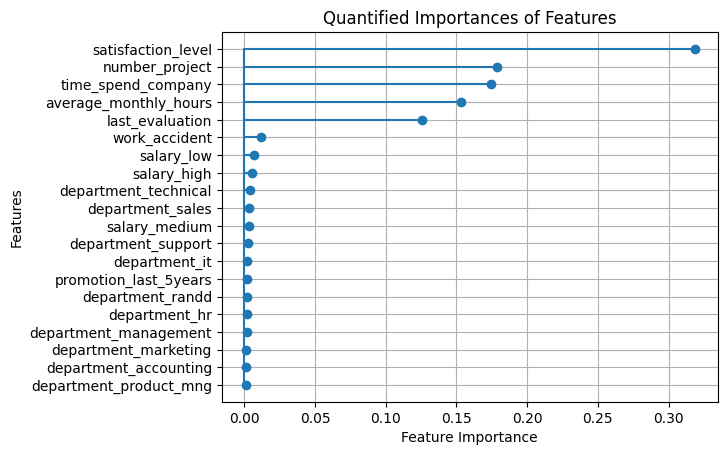

In [ ]:
plt.stem(df_feats['feature'] , df_feats['importance'] , orientation = 'horizontal', basefmt = '' )
plt.title('Quantified Importances of Features')
plt.ylabel('Features')
plt.xlabel('Feature Importance')
plt.gca().invert_yaxis() #reverse the default asecending order of the y-axis
plt.grid()
plt.show()

As we can see, we have a sparse set of feature variables. In other words, very few of our features contribute to the outcome of our target variable.

$\approx$ 25% of the features (five out of twenty) are responsible for $\approx$ 95% of the total feature importance.

## Create a Dataframe of Our Churn Predictions

Finally, let's create a dataframe of our churn predictions. Which will mirror `df2_processed` except for the two additional columns on it's end. One for the model's churn prediction and the churn probability score for that given employee.

Then we will export this new dataframe , along with our feature importance dataframe, back to BigQuery. So that we can use them in our Looker Studio dashboard.

In [ ]:
#set up intermediary dataframes
X2 = df2_processed.drop(columns = ['quit_the_company', 'employee_id'])
df_ids = df2_processed[['quit_the_company' ,'employee_id']]

#X_train, y_train, id_train, X_test, y_test, id_test = train_test_split(X2, y2, df_ids, test_size=0.2 , random_state = 42 )


y_pred_final = model_rf.predict(X2)
y_pred_proba = model_rf.predict_proba(X2)[:,1]

#final df with quit_the_company + predictions + churn proba

df2_final = df2_processed
df2_final['churn_prediction'] = y_pred_final
df2_final['churn_probability'] = y_pred_proba

df2_final.head(25)



,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,quit_the_company,promotion_last_5years,employee_id,salary_high,...,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,churn_prediction,churn_probability
0,0.537849,0.122914,2,208,2,0,0,0,NE15043,1,...,0,0,0,0,0,0,0,0,0.0,0.00
1,0.056211,0.322600,2,229,5,1,0,0,NE15086,0,...,0,0,0,0,0,0,0,0,0.0,0.33
2,0.555186,0.555949,2,187,3,0,0,0,NE15035,0,...,0,0,0,0,0,0,0,0,0.0,0.02
3,0.605273,0.713086,2,218,3,0,0,0,NE15069,1,...,0,0,0,0,0,0,0,0,0.0,0.03
4,0.043437,0.162372,2,175,3,0,0,0,NE15082,1,...,0,0,0,0,0,0,0,0,0.0,0.41
5,0.191650,0.401752,2,152,2,1,0,0,NE15092,0,...,1,0,0,0,0,0,0,0,0.0,0.28
6,0.586597,0.606792,2,197,4,1,0,0,NE15097,1,...,0,1,0,0,0,0,0,0,0.0,0.00
7,0.215623,0.767678,2,142,3,1,0,0,NE15102,0,...,0,1,0,0,0,0,0,0,0.0,0.11
8,0.519622,0.998394,2,206,4,1,0,0,NE15029,1,...,0,0,1,0,0,0,0,0,0.0,0.03
9,0.509265,0.457986,2,246,3,0,0,0,NE15040,1,...,0,0,1,0,0,0,0,0,0.0,0.07


## Exploring the Model's Predictions

At risk of churn by department (horizontal bar chart)

In [ ]:
df_churn = df2_final[df2_final['churn_prediction'] == 1]
churn_departments = [x for x in df_churn.columns if x.startswith('department_')]

churn_departments

for x in churn_departments: #rename department columns to omit "department_" prefix
  df_churn.rename( columns = {x : x.split("_")[1]} , inplace = True)

/tmp/ipython-input-2711950591.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_churn.rename( columns = {x : x.split("_")[1]} , inplace = True)


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'work_accident',
       'quit_the_company', 'promotion_last_5years', 'employee_id',
       'salary_high', 'salary_low', 'salary_medium', 'it', 'randd',
       'accounting', 'hr', 'management', 'marketing', 'product', 'sales',
       'support', 'technical', 'churn_prediction', 'churn_probability'],
      dtype='object')

In [ ]:
df_churn

depart_names_truncated = [x.split("_")[1] for x in churn_departments]

depart_tally = dict()


for x in depart_names_truncated:
  if int(df_churn[x].sum() > 0 ): # only include departments with a nonzero count
    depart_tally[x] = int(df_churn[x].sum())



In [ ]:
depart_tally

{'it': 1, 'management': 2, 'sales': 2, 'support': 2, 'technical': 1}

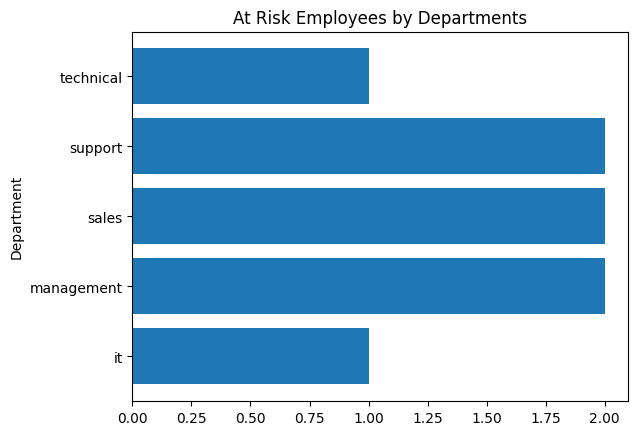

In [ ]:
plt.barh(depart_tally.keys() , depart_tally.values() )
plt.title("At Risk Employees by Departments")
plt.ylabel("Department")
#plt.xlabel("Count")
plt.show()

In [ ]:
df_depchurn = pd.DataFrame.from_dict(depart_tally, orient='index', columns=['count']).reset_index()
df_depchurn.rename(columns={'index': 'department'}, inplace=True)
df_depchurn

,department,count
0,it,1
1,management,2
2,sales,2
3,support,2
4,technical,1


Average values of top 5 features for those at risk of churning

In [ ]:
means = dict()

for x in df_feats['feature'][0:5]: #iterate through the most important features
  means[x] = float(df_churn[x].mean())


means

df_churn_avgs = pd.DataFrame.from_dict(means, orient= 'index' , columns = ['average'] )
df_churn_avgs

,average
satisfaction_level,0.275993
number_project,3.875000
time_spend_company,3.375000
average_monthly_hours,275.250000
last_evaluation,0.504686


## Export to BigQuery

In [ ]:
#send feature importance to a Big Query table
df_feats.to_gbq('employeedata.feature_table',
                project_id ,
                chunksize=None,
                if_exists='replace')

#send at-risk count by department to a Big Query table
df_depchurn.to_gbq('employeedata.at_risk_dept_count',
                   project_id,
                   chunksize = None,
                   if_exists = 'replace')


#send average values for at risk employees to a Big Query table

df_churn_avgs.to_gbq('employeedata.at_risk_avgs',
                     project_id,
                     chunksize = None,
                     if_exists = 'replace')

/tmp/ipython-input-3466428758.py:2: FutureWarning: Starting with pandas version 3.0 all arguments of to_gbq except for the argument 'destination_table' will be keyword-only.
  df_feats.to_gbq('employeedata.feature_table',
/tmp/ipython-input-3466428758.py:2: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  df_feats.to_gbq('employeedata.feature_table',
100%|██████████| 1/1 [00:00<00:00, 4519.72it/s]
/tmp/ipython-input-3466428758.py:8: FutureWarning: Starting with pandas version 3.0 all arguments of to_gbq except for the argument 'destination_table' will be keyword-only.
  df_depchurn.to_gbq('employeedata.at_risk_dept_count',
/tmp/ipython-input-3466428758.py:8: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  df_dep

In [ ]:
#send our final predictions to Big Query
df2_final.to_gbq('employeedata.churn_predictions',
                project_id,
                chunksize=None,
                if_exists ='replace')